In [1]:
import numpy as np
from scipy.integrate import solve_ivp
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
from scipy.optimize import minimize


## Model Definition

In [ ]:
class ControlMenstrualModel:
    def __init__(self, 
                 compartments=None, 
                 initial_hormones=None,
                 time_domain=(0, 1),
                 resolution=100,
                 parameters=None):
        """
        compartments: list of compartment names
        initial_hormones: dict with initial values for each compartment
        time_domain: tuple (t0, tf)
        resolution: number of time points
        parameters: nested dictionary of synthesis, clearance, and regulatory parameters
        """
        # Default compartments
        self.compartments = ['GnRH', 'LH', 'Estrogen'] if compartments is None else compartments
        self.compartment_to_index = {name: i for i, name in enumerate(self.compartments)}
        
        # Time domain
        self.time_domain = time_domain
        self.resolution = resolution
        self.t = np.linspace(time_domain[0], time_domain[1], resolution)
        
        # Parameters
        self.params = self._create_default_params() if parameters is None else self._create_default_params() | parameters
        
        # Initial hormone values
        if not isinstance(initial_hormones, dict):
            raise ValueError("Need a dictionary of initial conditions")
        if set(self.compartments) != set(initial_hormones.keys()):
            raise ValueError(f"Compartments and initial conditions keys must match!\n"
                             f"Compartments: {self.compartments}\n"
                             f"Initial conditions: {list(initial_hormones.keys())}")
        self.y0 = self._create_initial_condition(**initial_hormones)
    
    def _create_initial_condition(self, **initial_hormones):
        y0 = np.zeros(len(self.compartments))
        for comp in self.compartments:
            y0[self.compartment_to_index[comp]] = initial_hormones[comp]
        return y0
    
    def unpack(self, y):
        """Return a dict mapping compartment names to values."""
        return {comp: y[self.compartment_to_index[comp]] for comp in self.compartments}
    
    # Hill functions
    @staticmethod
    def hill_activate(K, n, P):
        P = np.maximum(P, 1e-12)
        K = np.maximum(K, 1e-12)
        n = np.maximum(n, 1e-12)

        Pn = np.exp(n * np.log(P))
        Kn = np.exp(n * np.log(K))

        return Pn / (Kn + Pn)


    @staticmethod
    def hill_repress(K, n, P):
        P = np.maximum(P, 1e-12)
        K = np.maximum(K, 1e-12)
        n = np.maximum(n, 1e-12)

        Pn = np.exp(n * np.log(P))
        Kn = np.exp(n * np.log(K))

        return Kn / (Kn + Pn)
    
    @staticmethod
    def hill_biphasic(K1, K2, n1, n2, P):
        return MenstrualModel.hill_activate(K1, n1, P) * MenstrualModel.hill_repress(K2, n2, P)
    
    def ode(self, t, y):
        h = self.unpack(y)
        GnRH, LH, Estrogen = h['GnRH'], h['LH'], h['Estrogen']

        #clamping the hormones to avoid numerical instability
        GnRH = max(GnRH, 1e-8)
        LH = max(LH, 1e-8)
        Estrogen = max(Estrogen, 1e-8)
        
        # ---------------- GnRH ----------------
        synth_E_on_GnRH = self.params['synthesis']['GnRH']
        clearance_GnRH = self.params['clearance']['GnRH']
        n_EGnRH1, n_EGnRH2 = self.params['regulatory'][('Estrogen', 'GnRH')]['n']
        K_EGnRH1, K_EGnRH2 = self.params['regulatory'][('Estrogen', 'GnRH')]['K']
        
        dGnRH = (synth_E_on_GnRH * (self.hill_biphasic(K_EGnRH1, K_EGnRH2, n_EGnRH1, n_EGnRH2, Estrogen))
                 - clearance_GnRH * GnRH)
        
        # ---------------- LH ----------------
        synth_LH_GnRH = self.params['synthesis']['LH']
        clearance_LH = self.params['clearance']['LH']
        n_GLH = self.params['regulatory'][('GnRH', 'LH')]['n']
        K_GLH = self.params['regulatory'][('GnRH', 'LH')]['K']
        
        dLH = (synth_LH_GnRH * self.hill_activate(K_GLH, n_GLH, GnRH)
               - clearance_LH * LH)
        
        # ---------------- Estrogen ----------------
        synth_Estrogen = self.params['synthesis']['Estrogen']
        clearance_Estrogen = self.params['clearance']['Estrogen']
        n_L_E1, n_L_E2 = self.params['regulatory'][('LH', 'Estrogen')]['n']
        K_L_E1, K_L_E2 = self.params['regulatory'][('LH', 'Estrogen')]['K']
        
        dEstrogen = (synth_Estrogen * (self.hill_biphasic(K_L_E1, K_L_E2, n_L_E1, n_L_E2, LH))
                     - clearance_Estrogen * Estrogen)
        
        return np.array([dGnRH, dLH, dEstrogen])
    
    def simulate(self, method='RK45'):
        """Simulate the ODE system over the time domain."""
        sol = solve_ivp(fun=self.ode, t_span=self.time_domain, y0=self.y0,
                        t_eval=self.t, method=method)
        return sol
    
    def _create_default_params(self):
        """Return a default parameter dictionary."""
        return {
            'synthesis': {
                'GnRH': 2.44,
                'LH': 6.35,
                'Estrogen': 2.45
            },
            'clearance': {
                'GnRH': 0.17,
                'LH': 0.35,
                'Estrogen': 0.09
            },
            'regulatory': {
                ('Estrogen', 'GnRH'): {
                    'n': (10.00, 4.41),
                    'K': (0.16, 0.56)
                },
                ('GnRH', 'LH'): {
                    'n': 5.73,
                    'K': 6.62
                },
                ('LH', 'Estrogen'): {
                    'n': (6.76, 10.00),
                    'K': (9.75, 20.25)
                }
            }
        }
    
    def plot(self, sol, compartments=None, title="Menstrual Cycle Model", ylim=None, axis=None, plot_day_14 = False):
        axis = plt.gca() if axis == None else axis
        ylim = (0, 8) if ylim == None else ylim

        if compartments is None:
            compartments=self.compartments
            
        for name in compartments:
            if name not in self.compartments:
                raise ValueError(f"Trying to plot nonexistent compartment: {name}")
            i = self.compartment_to_index[name]
            axis.plot(sol.t, sol.y[i], label=name)
        
        if plot_day_14:
            axis.vlines(x=14, ymin=ylim[0], ymax=ylim[1], linestyles='--', colors='black')
        
        axis.set(xlabel='Days', ylabel='Hormone Concentrations', title=title, ylim=ylim)
        plt.legend(loc="upper right")

In [3]:
initial_conditions = {
    'GnRH': 1.0,
    'LH': 0.25,
    'Estrogen': 1.0
}

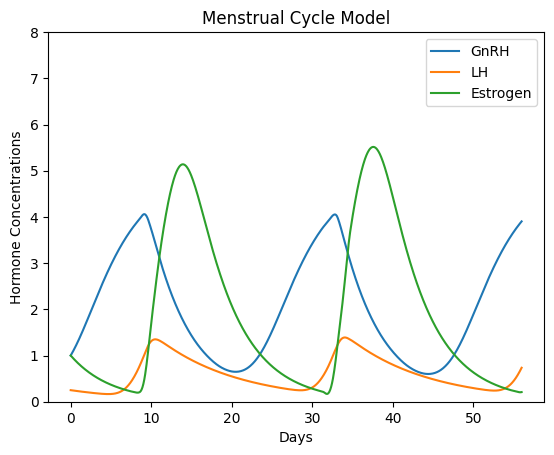

In [4]:
parameters = {
    'synthesis': {
        'GnRH': 1.0,  # (GnRH autoregulation, Estrogen effect)
        'LH': 1.0,    # (GnRH effect, Estrogen effect)
        'Estrogen': 2.0       # (LH effect)
    },
    'clearance': {
        'GnRH': 0.2,
        'LH': 0.1,
        'Estrogen': 0.2
    },
    'regulatory': {
        ('Estrogen', 'GnRH'): {'n': (10, 3), 'K': (0.09, 1.0)},
        ('GnRH', 'LH'): {'n': 12, 'K': 4.0},
        ('LH', 'Estrogen'): {'n': (10, 10), 'K': (1.0, 20.0)}
    }
}

model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 2 * 28), resolution=1000, parameters=parameters)
sol = model.simulate()
model.plot(sol)

## Fitting to data from PhD disertation

### helper functions

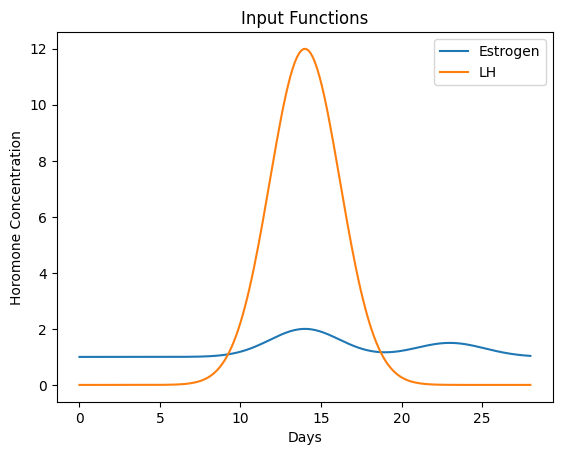

In [74]:
def plot_input_data(xlim = None, resolution = 200):
    xlim = (0, 28) if xlim == None else xlim
    estradiol_function = lambda x: 1 + 1 * np.exp(-(x-14)**2/(9.5)) + 0.5 * np.exp(-(x-23)**2/(9.5)) + 1 * np.exp(-(x-42)**2/(9.5))+ 0.5 * np.exp(-(x-51)**2/(9.5))
    LH_function = lambda x: 0 + 12 * np.exp(-(x-14)**2/(9.5)) + 12 * np.exp(-(x-42)**2/(9.5))
    x = np.linspace(xlim[0], xlim[1], resolution)
    plt.plot(x, estradiol_function(x), label='Estrogen')
    plt.plot(x, LH_function(x), label='LH')
    plt.gca().set(xlabel='Days', ylabel='Horomone Concentration', ylim=(0, 8), title='Input Functions')
    plt.autoscale(enable=True, axis='y', tight=False)
    plt.legend()

plot_input_data()
plt.savefig("figures/InputFunctions.pdf")

In [6]:
def unpack_params(p):
    return (
        # synthesis
        p['synthesis']['GnRH'],
        p['synthesis']['LH'],
        p['synthesis']['Estrogen'],

        # clearance
        p['clearance']['GnRH'],
        p['clearance']['LH'],
        p['clearance']['Estrogen'],

        # regulatory: Estrogen -> GnRH
        *p['regulatory'][('Estrogen', 'GnRH')]['n'],
        *p['regulatory'][('Estrogen', 'GnRH')]['K'],

        # regulatory: GnRH -> LH
        p['regulatory'][('GnRH', 'LH')]['n'],
        p['regulatory'][('GnRH', 'LH')]['K'],

        # regulatory: LH -> Estrogen
        *p['regulatory'][('LH', 'Estrogen')]['n'],
        *p['regulatory'][('LH', 'Estrogen')]['K'],
    )

def pack_params(theta):
    it = iter(theta)

    return {
        'synthesis': {
            'GnRH': next(it),
            'LH': next(it),
            'Estrogen': next(it)
        },
        'clearance': {
            'GnRH': next(it),
            'LH': next(it),
            'Estrogen': next(it)
        },
        'regulatory': {
            ('Estrogen','GnRH'): {
                'n': (next(it), next(it)),
                'K': (next(it), next(it))
            },
            ('GnRH','LH'): {
                'n': next(it),
                'K': next(it)
            },
            ('LH','Estrogen'): {
                'n': (next(it), next(it)),
                'K': (next(it), next(it))
            }
        }
    }

In [46]:
estradiol_function = lambda x: 1 + 1 * np.exp(-(x-14)**2/(9.5)) + 0.5 * np.exp(-(x-23)**2/(9.5)) + 1 * np.exp(-(x-42)**2/(9.5))+ 0.5 * np.exp(-(x-51)**2/(9.5))
LH_function = lambda x: 0 + 12 * np.exp(-(x-14)**2/(9.5)) + 12 * np.exp(-(x-42)**2/(9.5))

def calculate_error(param):
    
    param_dict = pack_params(param)
    model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 62), resolution=400, parameters=param_dict)
    sol = model.simulate()

    #using soft rejections to avoid finding areas where there is no gradient
    if not sol.success or np.any(np.isnan(sol.y)):
        return 1e6 + np.sum(param**2)

    if np.any(sol.y > 1e6):
        return 1e6 + np.max(sol.y)

    diff_e = sol.y[model.compartment_to_index["Estrogen"]] - estradiol_function(sol.t)
    diff_l = sol.y[model.compartment_to_index['LH']] - LH_function(sol.t)
    return  (1.1*np.linalg.norm((diff_e))**2 + 1.1 * np.linalg.norm(diff_l)**2)
    

In [47]:
bounds = [
    # synthesis
    (1e-6, 20),   # GnRH synthesis
    (1e-6, 20),   # LH synthesis
    (1e-6, 20),   # Estrogen synthesis

    # clearance
    (1e-6, 5),    # GnRH clearance
    (1e-6, 5),    # LH clearance
    (1e-6, 5),    # Estrogen clearance

    # Estrogen -> GnRH (n1, n2)
    (1, 10),
    (1, 10),

    # Estrogen -> GnRH (K1, K2)
    (1e-3, 50),
    (1e-3, 50),

    # GnRH -> LH (n)
    (1, 10),

    # GnRH -> LH (K)
    (1e-3, 50),

    # LH -> Estrogen (n1, n2)
    (1, 10),
    (1, 10),

    # LH -> Estrogen (K1, K2)
    (1e-3, 50),
    (1e-3, 50),
]

### Optimization Step

In [58]:
potential_parameters3 = {'synthesis': {'GnRH': 2, 'LH': 6, 'Estrogen': 2}, 'clearance': {'GnRH': 0.13, 'LH': 0.31, 'Estrogen': 0.15}, 'regulatory': {('Estrogen', 'GnRH'): {'n': (10, 4.26), 'K': (0.15, 0.50)}, ('GnRH', 'LH'): {'n': 5.62, 'K': 5.93}, ('LH', 'Estrogen'): {'n': (6.90, 10.0), 'K': (10, 20.0)}}}


In [59]:
params = unpack_params(potential_parameters3)
result = minimize(calculate_error, params, options={"maxiter": 1000, 'maxls': 100, "disp": True}, tol=1e-12, bounds=bounds, method='L-BFGS-B')
best_parameters = pack_params(result.x)

In [60]:
print(best_parameters)


{'synthesis': {'GnRH': 2.439633939240153, 'LH': 6.347471033428871, 'Estrogen': 2.4489791844085227}, 'clearance': {'GnRH': 0.1671894191663751, 'LH': 0.3472675276033746, 'Estrogen': 0.0949711152587191}, 'regulatory': {('Estrogen', 'GnRH'): {'n': (9.999893629991886, 4.405322314307441), 'K': (0.15812841707282657, 0.564190700871667)}, ('GnRH', 'LH'): {'n': 5.726096877040471, 'K': 6.617241005912405}, ('LH', 'Estrogen'): {'n': (6.757129016715701, 9.999989565655795), 'K': (9.749653400451571, 20.24592759016965)}}}


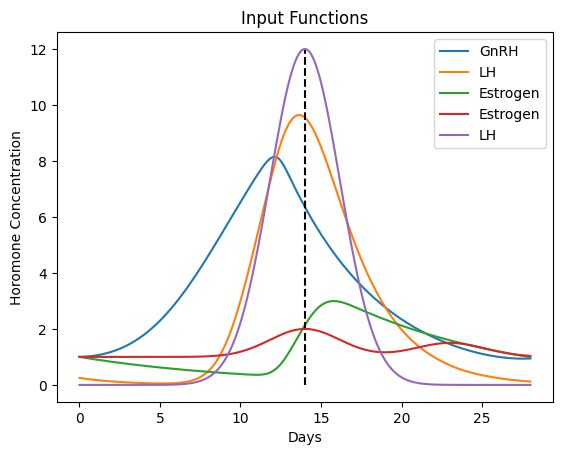

In [61]:
model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 1*28), resolution=200, parameters=best_parameters)
sol = model.simulate()
model.plot(sol, plot_day_14=True, ylim=(0, 12))
plot_input_data()

### Good Parameter Set 1

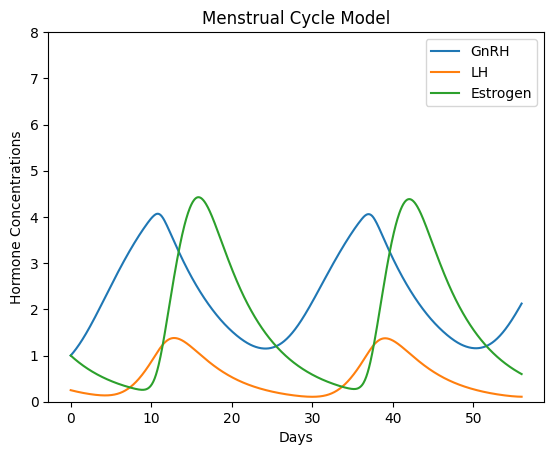

In [13]:
potential_parameters = {
    'synthesis': {
        'GnRH': 0.72,
        'LH': 0.99,
        'Estrogen': 2.05
    },
    'clearance': {
        'GnRH': 0.12,
        'LH': 0.18,
        'Estrogen': 0.16
    },
    'regulatory': {
        ('Estrogen', 'GnRH'): {
            'n': (6.00, 2.99),
            'K': (0.08, 0.92)
        },
        ('GnRH', 'LH'): {
            'n': 6.00,
            'K': 4.16
        },
        ('LH', 'Estrogen'): {
            'n': (5.64, 6.00),
            'K': (1.18, 20.00)
        }
    }
}

model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 2*28), resolution=1000, parameters=potential_parameters)
sol = model.simulate()
model.plot(sol)


### Good Parameter Set 2

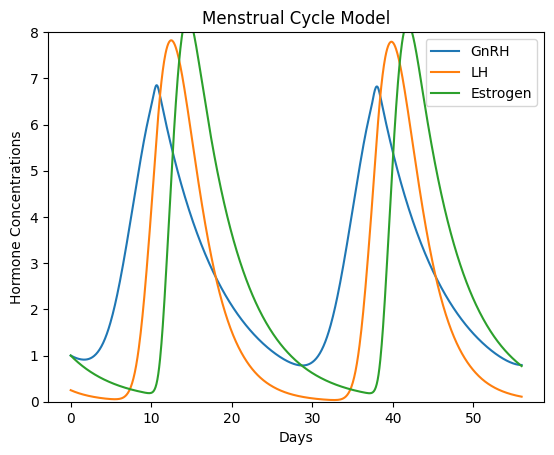

In [14]:
potential_parameters2 = {'synthesis': {'GnRH': 1.881570358425819, 'LH': 5.933149093881693, 'Estrogen': 8.187683301977076}, 'clearance': {'GnRH': 0.13000617656597083, 'LH': 0.3067048084905143, 'Estrogen': 0.1767308951793158}, 'regulatory': {('Estrogen', 'GnRH'): {'n': (9.998655901831478, 4.264006109570467), 'K': (0.15238630618477622, 0.39543036930458536)}, ('GnRH', 'LH'): {'n': 5.6198200973955315, 'K': 5.9303541491918095}, ('LH', 'Estrogen'): {'n': (6.897795014253463, 9.999995916078644), 'K': (7.891117441817578, 20.00000004328206)}}}
model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 2*28), resolution=1000, parameters=potential_parameters2)
sol = model.simulate()
model.plot(sol)

### Good Parameter Set 3

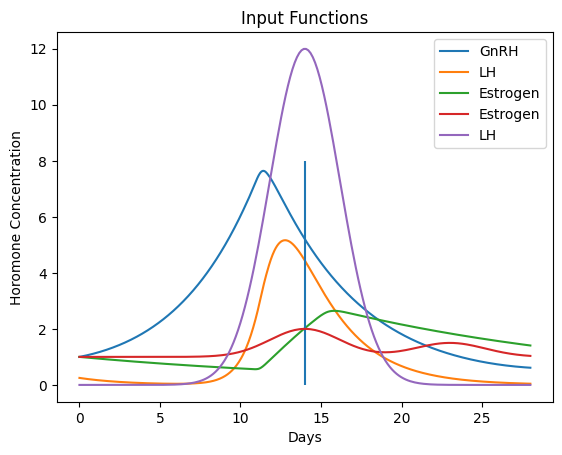

In [15]:
potential_parameters3 = {'synthesis': {'GnRH': 19.080747653063103, 'LH': 8.963555194404625, 'Estrogen': 0.6056126877969}, 'clearance': {'GnRH': 0.17875227099155017, 'LH': 0.3430667974310022, 'Estrogen': 0.053340734727207635}, 'regulatory': {('Estrogen', 'GnRH'): {'n': (6.015909299621474, 4.047512877455463), 'K': (0.08960562158967206, 0.35737934691168777)}, ('GnRH', 'LH'): {'n': 6.000006411562403, 'K': 8.118882087275408}, ('LH', 'Estrogen'): {'n': (10.960342694057574, 6.000006594059802), 'K': (3, 20.000071881535508)}}}
model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 1*28), resolution=1000, parameters=potential_parameters3)
sol = model.simulate()
model.plot(sol)
plt.vlines(x=14, ymin=0, ymax=8)
plot_input_data()

### Best Parameters

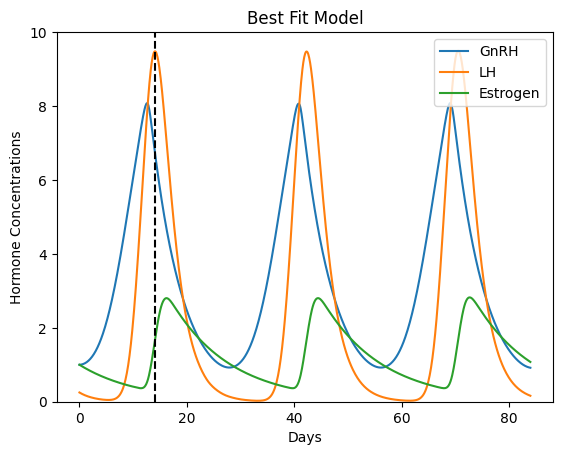

In [105]:
params = {
 'synthesis': {
     'GnRH': 2.44,
     'LH': 6.35,
     'Estrogen': 2.45
 },
 'clearance': {
     'GnRH': 0.17,
     'LH': 0.35,
     'Estrogen': 0.09
 },
 'regulatory': {
     ('Estrogen', 'GnRH'): {
         'n': (10.00, 4.41),
         'K': (0.16, 0.56)
     },
     ('GnRH', 'LH'): {
         'n': 5.73,
         'K': 6.62
     },
     ('LH', 'Estrogen'): {
         'n': (6.76, 10.00),
         'K': (9.75, 20.25)
     }
 }
}

model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 3*28), resolution=1000, parameters=params)
sol = model.simulate()
model.plot(sol, plot_day_14=True, ylim=(0, 10), title="Best Fit Model")
plt.savefig("figures/best_fit.pdf")

## Figure Generating for Paper

### Hill Function Plotting

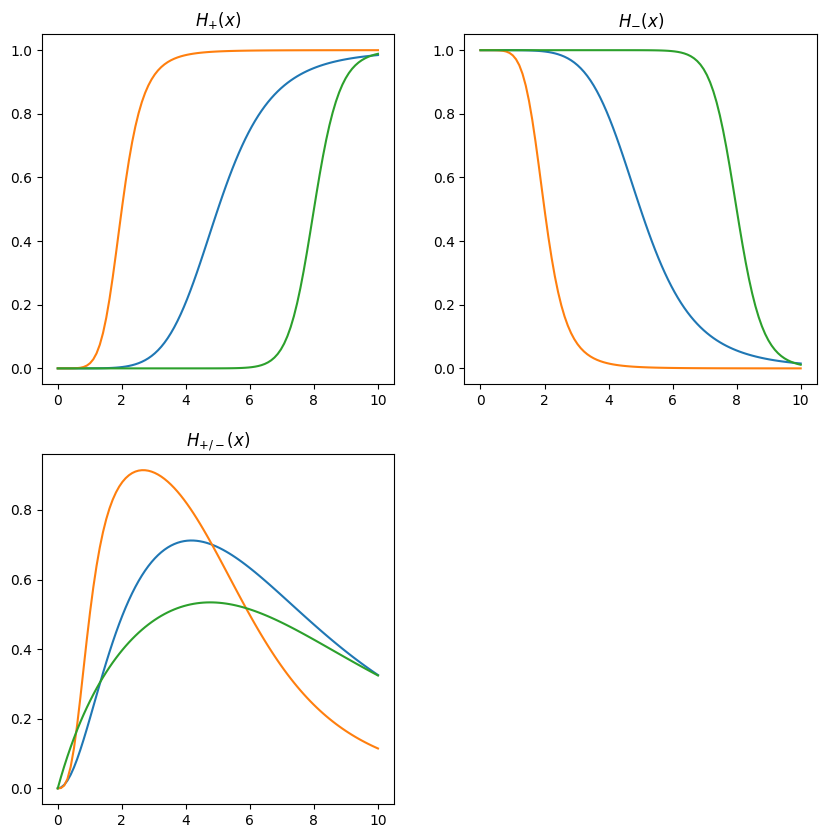

In [109]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()
axes[3].set_axis_off()
activation_parameters = [(5, 6), (2, 6), (8, 20)]
domain = np.linspace(0, 10, 100)
for K, n in activation_parameters:
    axes[0].plot(domain, MenstrualModel.hill_activate(K, n, domain), label=r'$K=$' + f'{K}' + r' $n=$' + f'{n}')
    axes[0].set_title(r"$H_{+}(x)$")
inhibit_parameters = [(5, 6), (2, 6), (8, 20)]
for K, n in inhibit_parameters:
        axes[1].plot(domain, MenstrualModel.hill_repress(K, n, domain), label=r'$K=$' + f'{K}' + r' $n=$' + f'{n}')
        axes[1].set_title(r"$H_{-}(x)$")
biphasic_parameters = [
    (2.0, 2, 8.0, 3),   # Moderate activation at low x, inhibition at high x
    (1.0, 3, 6.0, 4),   # Stronger low-x activation, sharper high-x inhibition
    (3.0, 1, 9.0, 3)    # Shallow activation, delayed inhibition
]
for K1, n1, K2, n2 in biphasic_parameters:
        axes[2].plot(domain, MenstrualModel.hill_biphasic(K1, K2, n1, n2, domain), label=r'$K1, K2=$' + f'{K1, K2}' + r' $n1, n2 =$' + f'{n1, n2}')
        axes[2].set_title(r"$H_{+/-}(x)$")

plt.savefig("HillFunctions.pdf")

### Parameter Sensitivity Plotting

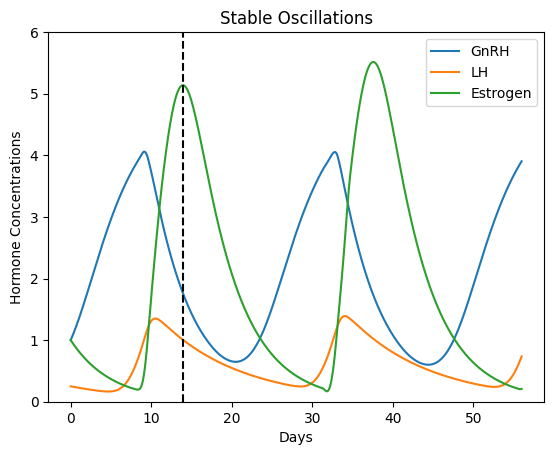

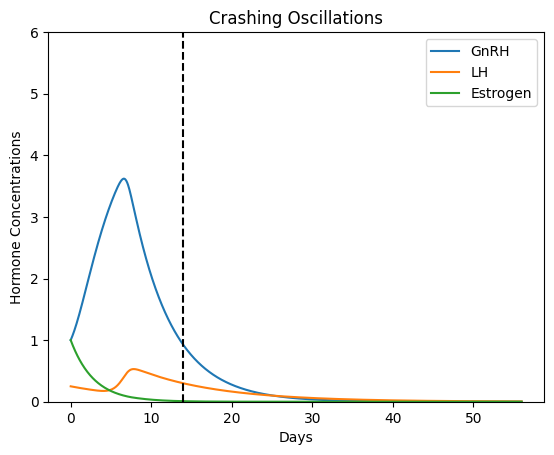

In [103]:
parameters1 = {
    'synthesis': {
        'GnRH': 1.0,  # (GnRH autoregulation, Estrogen effect)
        'LH': 1.0,    # (GnRH effect, Estrogen effect)
        'Estrogen': 2.0       # (LH effect)
    },
    'clearance': {
        'GnRH': 0.2,
        'LH': 0.1,
        'Estrogen': 0.2
    },
    'regulatory': {
        ('Estrogen', 'GnRH'): {'n': (10, 3), 'K': (0.09, 1.0)},
        ('GnRH', 'LH'): {'n': 12, 'K': 4.0},
        ('LH', 'Estrogen'): {'n': (10, 10), 'K': (1.0, 20.0)}
    }
}

parameters2 = {
    'synthesis': {
        'GnRH': 1.0,  # (GnRH autoregulation, Estrogen effect)
        'LH': 1.0,    # (GnRH effect, Estrogen effect)
        'Estrogen': 2.0       # (LH effect)
    },
    'clearance': {
        'GnRH': 0.2,
        'LH': 0.1,
        'Estrogen': 0.35
    },
    'regulatory': {
        ('Estrogen', 'GnRH'): {'n': (10, 3), 'K': (0.09, 1.0)},
        ('GnRH', 'LH'): {'n': 12, 'K': 4.0},
        ('LH', 'Estrogen'): {'n': (10, 10), 'K': (1.0, 20.0)}
    }
}


model1 = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 2 * 28), resolution=1000, parameters=parameters1)
sol1 = model1.simulate()
model1.plot(sol1, plot_day_14=True, title='Stable Oscillations', ylim=(0, 6))
plt.savefig("figures/first_oscillations.pdf")
plt.show()
model2 = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 2 * 28), resolution=1000, parameters=parameters2)
sol2 = model2.simulate()
model2.plot(sol2, ylim=(0,6), title="Crashing Oscillations", plot_day_14=True)
plt.savefig("figures/crash_oscillations.pdf")

### Comparing Best Fit and Input Data

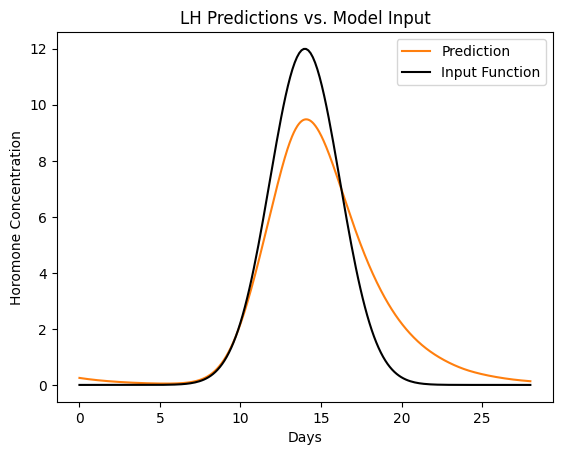

In [96]:
params = {
 'synthesis': {
     'GnRH': 2.44,
     'LH': 6.35,
     'Estrogen': 2.45
 },
 'clearance': {
     'GnRH': 0.17,
     'LH': 0.35,
     'Estrogen': 0.09
 },
 'regulatory': {
     ('Estrogen', 'GnRH'): {
         'n': (10.00, 4.41),
         'K': (0.16, 0.56)
     },
     ('GnRH', 'LH'): {
         'n': 5.73,
         'K': 6.62
     },
     ('LH', 'Estrogen'): {
         'n': (6.76, 10.00),
         'K': (9.75, 20.25)
     }
 }
}

model = MenstrualModel(initial_hormones=initial_conditions, time_domain=(0, 1*28), resolution=1000, parameters=params)
sol = model.simulate()
plt.plot(sol.t, sol.y[1], color='tab:orange', label='Prediction')


xlim = (0, 1 * 28)
estradiol_function = lambda x: 1 + 1 * np.exp(-(x-14)**2/(9.5)) + 0.5 * np.exp(-(x-23)**2/(9.5)) + 1 * np.exp(-(x-42)**2/(9.5))+ 0.5 * np.exp(-(x-51)**2/(9.5))
LH_function = lambda x: 0 + 12 * np.exp(-(x-14)**2/(9.5)) + 12 * np.exp(-(x-42)**2/(9.5))
x = np.linspace(xlim[0], xlim[1], 200)
plt.plot(x, LH_function(x), label='Input Function', color='Black')
plt.gca().set(xlabel='Days', ylabel='Horomone Concentration', ylim=(0, 8), title='LH Predictions vs. Model Input')
plt.autoscale(enable=True, axis='y', tight=False)
plt.legend()
plt.savefig("figures/LH_prediction_vs_input.pdf")


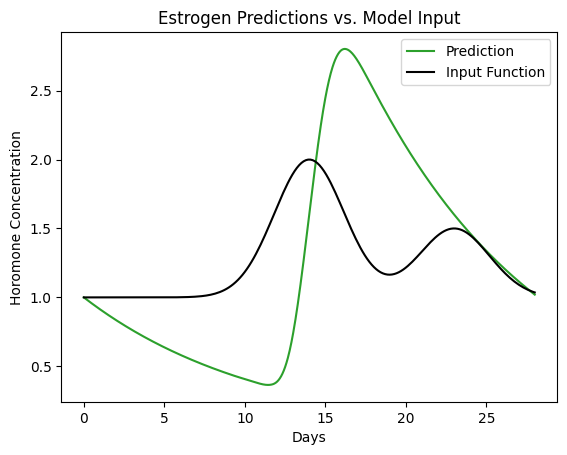

In [98]:
plt.plot(sol.t, sol.y[2], color='tab:green', label='Prediction')

xlim = (0, 1 * 28)
estradiol_function = lambda x: 1 + 1 * np.exp(-(x-14)**2/(9.5)) + 0.5 * np.exp(-(x-23)**2/(9.5)) + 1 * np.exp(-(x-42)**2/(9.5))+ 0.5 * np.exp(-(x-51)**2/(9.5))
x = np.linspace(xlim[0], xlim[1], 200)
plt.plot(x, estradiol_function(x), label='Input Function', color='Black')
plt.gca().set(xlabel='Days', ylabel='Horomone Concentration', ylim=(0, 8), title='Estrogen Predictions vs. Model Input')
plt.autoscale(enable=True, axis='y', tight=False)
plt.legend()
plt.savefig("figures/Estrogen_prediction_vs_input.pdf")